# 1.Introducción

En este taller trabajaremos con el Wine Dataset del repositorio de UCI, disponible en sklearn.

El objetivo es predecir la clase de vino a partir de variables químicas como la cantidad de alcohol, ácido málico, flavonoides, entre otros.

Preguntas:

¿Qué diferencia hay entre un problema de regresión y uno de clasificación?

En la regresión, buscamos un número, su objetivo es predecir un valor numérico continuo, como el precio de una casa o la edad de una persona.
En la clasificación, queremos decidir a qué grupo pertenece algo, se busca asignar una categoría o clase, por ejemplo si un correo es spam o no spam.

¿Por qué un árbol de decisión es adecuado para clasificación?

Porque un árbol de decisión divide los datos en ramas según sus características, separando los grupos paso a paso hasta llegar a una decisión final. Es fácil de interpretar, maneja bien datos tanto numéricos como categóricos y puede capturar relaciones no lineales entre las variables, lo que lo hace muy útil para tareas de clasificación.

# 2. Carga y exploración de datos

In [15]:
from sklearn.datasets import load_wine
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Cargar el dataset
wine = load_wine()

# Convertir a DataFrame
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

# Mostrar las primeras 15 filas del dataset
df.head(15)

# Muestra información general del dataset
df.info()

# Genera una tabla con la descripción de cada campo y su significado
df.describe()

# Revisar balance deacuerdo al numero de clases
df["target"].value_counts()

# Estadísticas descriptivas de variables
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Preguntas:

¿Qué librerías se usan para el manejo de datos y visualización?
RTA: Se usan pandas para manejar y analizar los datos en forma de tablas, seaborn y matplotlib.pyplot para crear gráficos y visualizar la información de manera más clara.

¿Qué librerías pertenecen a scikit-learn y para qué sirven?
RTA:
**sklearn.datasets:** para cargar conjuntos de datos de ejemplo como el de vino.
**sklearn.model_selection:** para dividir los datos en entrenamiento y prueba.
**sklearn.tree:** para crear y visualizar árboles de decisión.
**sklearn.metrics:** para medir el rendimiento del modelo, como la precisión y la matriz de confusión.

¿Están balanceadas las clases?
RTA: No. El conjunto de datos tiene 178 registros divididos en las tres clases targets 0, 1 y 2, pero no en cantidades iguales. Aunque las diferencias no son tan grandes, hay un leve desbalance entre ellas.

¿Por qué eso es importante en clasificación?
RTA: Porque si una clase tiene más ejemplos que las otras, el modelo puede aprender a favorecer la clase mayoritaria y tener peor rendimiento en las minoritarias. Un dataset equilibrado permite que el modelo aprenda de todas las clases por igual y tenga predicciones más justas y precisas.



# 3. Visualización de datos

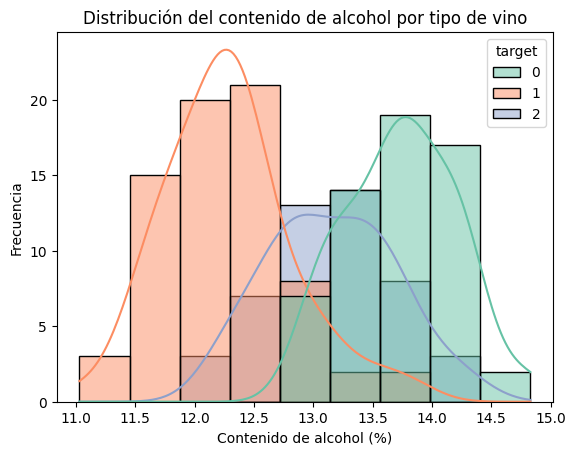

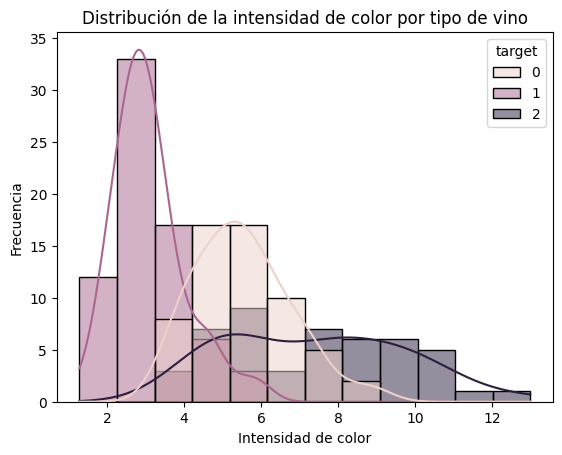

In [16]:
# Visualizar distribuciones de algunas variables (alcohol)
sns.histplot(data=df, x="alcohol", hue="target", kde=True, palette="Set2")
plt.title("Distribución del contenido de alcohol por tipo de vino")
plt.xlabel("Contenido de alcohol (%)")
plt.ylabel("Frecuencia")
plt.show()
sns.histplot(data=df, x="color_intensity", hue="target", kde=True)
plt.title("Distribución de la intensidad de color por tipo de vino")
plt.xlabel("Intensidad de color")
plt.ylabel("Frecuencia")
plt.show()

¿Qué correlación existe entre la variable x y hue?
RTA: El contenido de alcohol y la intensidad del color tienen cierta relación con el tono del vino. Mientras el alcohol tiende a aumentar el tono, una mayor intensidad de color parece reducirlo ligeramente. Sin embargo, ninguna de las dos relaciones es muy fuerte, puede ser que el tono depende de mas factores.

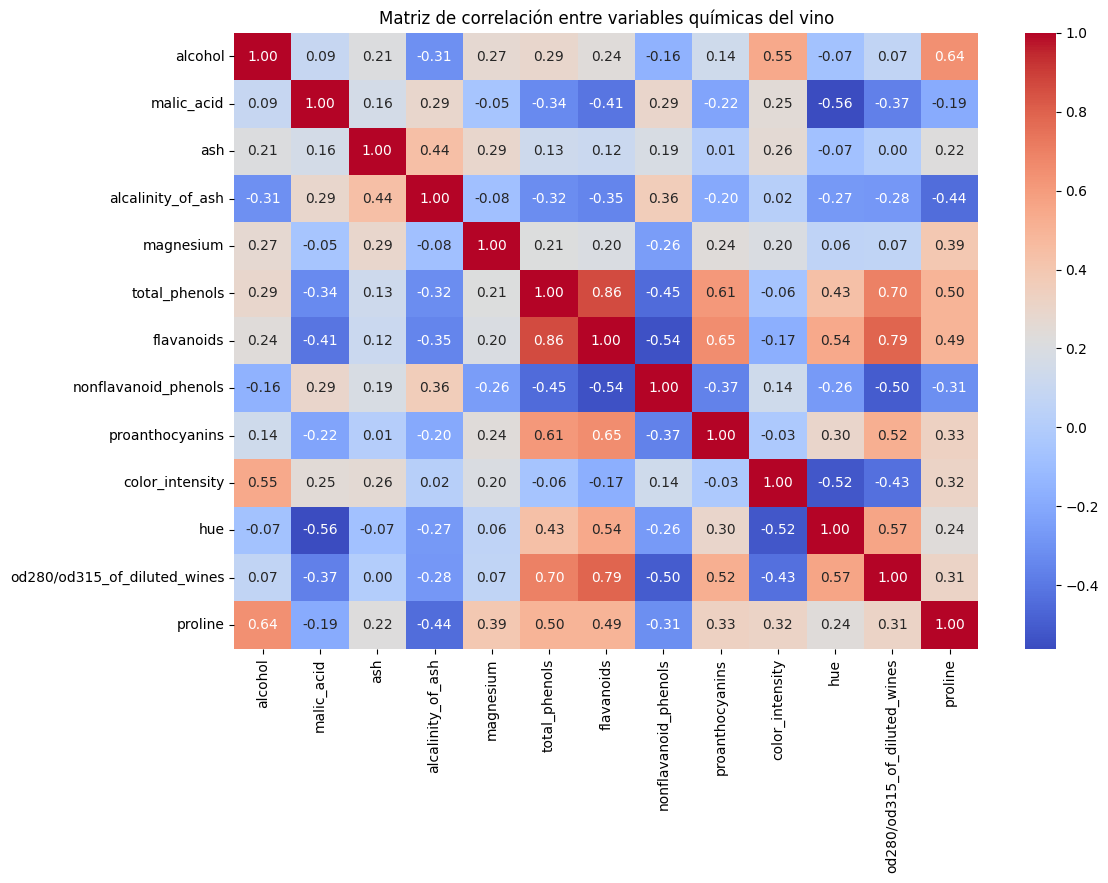

In [17]:
# Visualizar matriz de correlación de variables
corr = df.drop("target", axis=1).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", annot=True, fmt=".2f", cbar=True)
plt.title("Matriz de correlación entre variables químicas del vino")
plt.show()

¿Qué variables parecen más útiles para diferenciar clases?

RTA: Las variables que parecen más útiles para diferenciar las clases de vino son alcohol, proline, flavanoids, total_phenols y color_intensity. Estas destacan porque muestran una relación más fuerte con las demás variables y pueden influir directamente en las características que distinguen un tipo de vino de otro, como su sabor, color y cuerpo.

#4. Segmentación 70% Entrenamiento, 15% Validación, 15% Prueba

In [18]:
X = df.drop("target", axis=1)
y = df["target"]

# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 15% validación, 15% prueba (dividimos 30% en dos mitades iguales)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Mostrar cuántas filas tiene cada conjunto (Entrenamiento, Validación y Prueba)
print("Tamaño del conjunto de entrenamiento:", X_train.shape[0])
print("Tamaño del conjunto de validación:", X_valid.shape[0])
print("Tamaño del conjunto de prueba:", X_test.shape[0])

Tamaño del conjunto de entrenamiento: 124
Tamaño del conjunto de validación: 27
Tamaño del conjunto de prueba: 27


**¿Qué rol juega cada conjunto (train, validation, test)?**
RTA:
train: se usa para que el modelo aprenda, es decir, para ajustar sus parámetros a los datos.
validation: sirve para evaluar el rendimiento del modelo mientras se entrena y ajustar configuraciones.
test: se usa al final, con datos completamente nuevos, para medir qué tan bien generaliza el modelo en situaciones reales.

**¿Qué implicaciones tiene evaluar primero en prueba y después en validación?**
RTA: evaluar primero en el conjunto de prueba es un error, porque estarías usando datos que deben mantenerse “ocultos” hasta el final. Si se evalúa antes, se corre el riesgo de ajustar el modelo inconscientemente a esos datos, lo que genera resultados artificialmente buenos pero poca capacidad de generalización.

# 5. Entrenamiento del modelo

Precisión (accuracy) del modelo en validación: 0.96


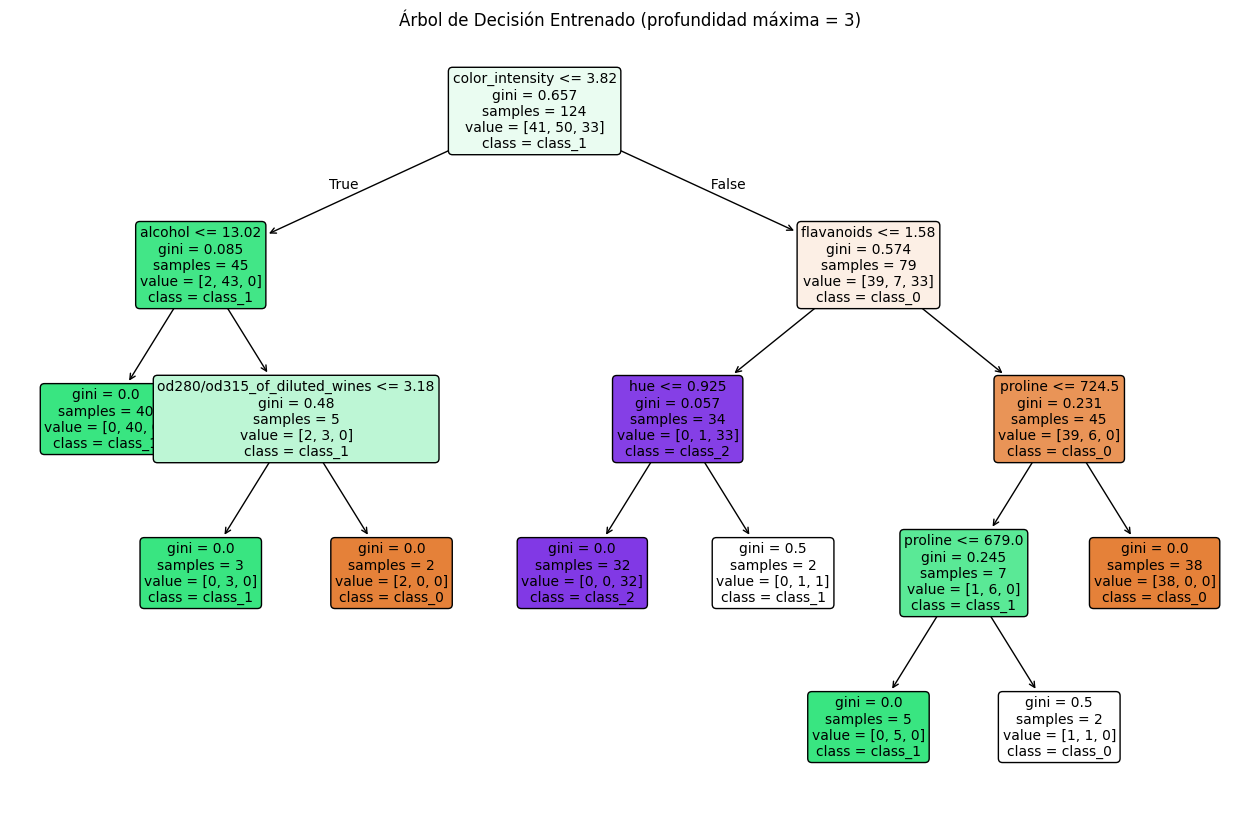

In [27]:
model = DecisionTreeClassifier(criterion="gini", max_depth=5, min_samples_split=4,  min_samples_leaf=2, random_state=0)
model.fit(X_train, y_train)

# Calcular Accuracy (porcentaje de aciertos)
y_pred = model.predict(X_valid)
accuracy = accuracy_score(y_valid, y_pred)
print(f"Precisión (accuracy) del modelo en validación: {accuracy:.2f}")

#Visualizar modelo entrenado
plt.figure(figsize=(16, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=[str(c) for c in wine.target_names],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión Entrenado (profundidad máxima = 3)")
plt.show()

**¿Qué significa el parámetro criterion="gini"?**
RTA: gini indica que el árbol usa el índice de Gini para medir la pureza de las divisiones. Evalúa qué tan homogéneos son los grupos creados; mientras más bajo el valor de Gini, más pura es la división.

**¿Qué pasaría si realizamos cambios al límite de max_depth?**
RTA: el árbol se vuelve más complejo y puede aprender demasiado del conjunto de entrenamiento, lo que lleva al sobreajuste.

**¿Qué variable aparece en la raíz del árbol?**
RTA: La variable en la raíz es color_intensity.

**¿Por qué crees que esa variable fue elegida?**
RTA: porque fue la que mas permitió separar las clases de vino en el primer paso. El modelo encontró que la intensidad de color genera una división que reduce más la impureza, lo que la hace clave para distinguir entre los tipos de vino.

**¿Cómo podrías interpretar las reglas del árbol?**
RTA: las reglas del árbol muestran las condiciones que el modelo usa para clasificar los vinos. Por ejemplo, si la intensidad de color ≤ 3.82, el árbol sigue una rama; si es mayor, sigue otra. Cada nodo aplica una comparación entre variables (como ash, flavanoids o proline), y al final, la hoja indica la clase de vino predicha.



#6. Evaluación en validación

Accuracy en validación: 0.96


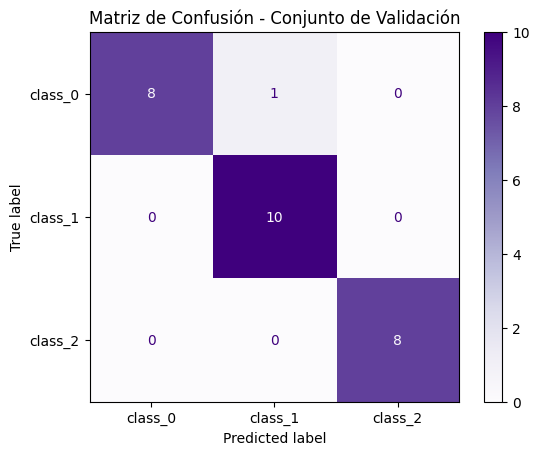

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

y_val_pred = model.predict(X_valid)

# Accuracy: porcentaje total de aciertos
val_accuracy = accuracy_score(y_valid, y_val_pred)
print(f"Accuracy en validación: {val_accuracy:.2f}")

# Visualizar matriz de confusión
cm = confusion_matrix(y_valid, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
disp.plot(cmap="Purples")
plt.title("Matriz de Confusión - Conjunto de Validación")
plt.show()

**¿Qué relación tiene la metrica de accuracy en la fase de entrenamiento y validación con el riesgo de overfitting?**
RTA: Si el accuracy en entrenamiento es mucho mayor que en validación, el modelo se sobreajustó y no generaliza bien. Si ambos valores son parecidos, el modelo está equilibrado y no hay riesgo de overfitting.

**¿Cómo interpreta los resultados en la fase de validación en relación con la matriz de confusión?**
RTA: El modelo clasifica casi todos los datos correctamente, con solo un error entre las clases 0 y 1. Esto muestra un buen desempeño y una validación coherente con lo aprendido.

#7. Evaluación en prueba

/tmp/ipython-input-4166517829.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_report.index[:-1], y=df_report["f1-score"][:-1], palette="Purples")


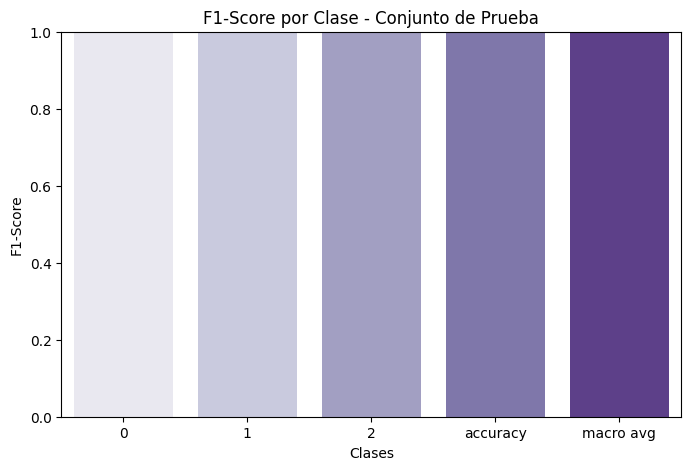

In [24]:
from sklearn.metrics import classification_report

y_test_pred = model.predict(X_test)

# Accuracy: porcentaje total de aciertos
report = classification_report(y_test, y_test_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
# Visualizar matriz de confusión
plt.figure(figsize=(8,5))
sns.barplot(x=df_report.index[:-1], y=df_report["f1-score"][:-1], palette="Purples")
plt.title("F1-Score por Clase - Conjunto de Prueba")
plt.ylabel("F1-Score")
plt.xlabel("Clases")
plt.ylim(0, 1)
plt.show()

**¿Qué información adicional da la matriz de confusión frente al accuracy?**
RTA: La matriz de confusión muestra qué clases se aciertan o confunden, no solo el porcentaje total de aciertos. Permite ver si el modelo tiene errores concentrados en una clase específica, algo que el accuracy por sí solo no revela.

**¿Qué se puede concluir del modelo en esta sección?**
RTA: El modelo tiene un desempeño muy alto y equilibrado en el conjunto de prueba, ya que los valores de F1-score son cercanos a 1 para todas las clases. Esto indica que generaliza bien y no presenta sobreajuste evidente.

#8. Reto

**Realiza mejoras para aumentar la metrica de accuracy, genera los cambios que crea coveniente.**
RTA: cambios realizados en la parte superior en el arbol